<a href="https://colab.research.google.com/github/Timmythaw/langgraph-adk-edu-comparison/blob/main/notebooks/01_langgraph_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

#### Install Dependencies

In [1]:
!pip install langgraph langchain-google-genai langchain-google-community \
    google-cloud-aiplatform google-cloud-discoveryengine \
    google-api-python-client google-auth-httplib2 google-auth-oauthlib \
    langsmith -q
!pip show langgraph

Name: langgraph
Version: 1.1.9
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain, langchain-google-community


#### Load Secrets

In [2]:
from google.colab import userdata

PROJECT_ID   = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION     = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

print("Project:",   PROJECT_ID[:15])
print("Location:",  LOCATION)
print("Datastore:", DATASTORE_ID[:15])

Project: edu-teacher-ass
Location: global
Datastore: curriculum-conn


In [3]:
# ─── LangSmith Unified Tracing ───────────────────────────────────────────────
import os
from google.colab import userdata

os.environ["LANGCHAIN_TRACING_V2"]  = "true"
os.environ["LANGCHAIN_API_KEY"]     = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"]     = "langgraph-adk-edu-comparison"
os.environ["LANGCHAIN_ENDPOINT"]    = "https://api.smith.langchain.com"

print("LangSmith tracing enabled")
print("  Project: ", os.environ["LANGCHAIN_PROJECT"])

LangSmith tracing enabled
  Project:  langgraph-adk-edu-comparison


#### Google Authentication

In [4]:
from google.colab import auth
auth.authenticate_user()

import google.auth
credentials, project = google.auth.default()
print("Authenticated")
print("Project:", project)

Authenticated
Project: 


#### Set Project and Verify

In [5]:
import os
import vertexai
from google.cloud import aiplatform

os.environ["GOOGLE_CLOUD_PROJECT"]  = PROJECT_ID
os.environ["GOOGLE_CLOUD_LOCATION"] = LOCATION

vertexai.init(project=PROJECT_ID, location="us-central1")
aiplatform.init(project=PROJECT_ID, location="us-central1")

print("Project:",  PROJECT_ID[:15])
print("Search Location:", LOCATION)
print("Datastore:", DATASTORE_ID[:15])
print("Vertex AI backend enabled for LangGraph")

Project: edu-teacher-ass
Search Location: global
Datastore: curriculum-conn
Vertex AI backend enabled for LangGraph


#### LangGraph Import & Version

In [6]:
from importlib.metadata import version
print("LangGraph version:", version("langgraph"))

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, Annotated, Literal
import operator

print("All LangGraph imports successful")

LangGraph version: 1.1.9


/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


All LangGraph imports successful


# Sub Nodes

In [7]:
def extract_text(response) -> str:
    """Extract plain text from ChatGoogleGenerativeAI response.
    Handles both plain string and list-of-parts (thinking model output)."""
    content = response.content
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        # Parts: thinking parts have type "thinking", text parts have type "text"
        text_parts = [
            p["text"] if isinstance(p, dict) else p.text
            for p in content
            if (isinstance(p, dict) and p.get("type") == "text")
            or (hasattr(p, "type") and p.type == "text")
        ]
        return "\n".join(text_parts).strip()
    return str(content)

#### Tool: Vertex AI Search

In [8]:
from google.cloud import discoveryengine_v1 as discoveryengine

def retrieve_course_materials(
    query: str,
    page_size: int = 5,
    summary_result_count: int = 3,
) -> str:
    """
    Search the curriculum datastore for relevant course materials.

    Args:
        query:                Natural language search query from the node.
        page_size:            Number of results to retrieve (tune per node).
        summary_result_count: Number of results used for AI summary.

    Returns:
        Concatenated snippet text, or "No relevant materials found."
    """
    client = discoveryengine.SearchServiceClient()

    serving_config = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}"
        f"/collections/default_collection/dataStores/{DATASTORE_ID}"
        f"/servingConfigs/default_config"
    )

    request = discoveryengine.SearchRequest(
        serving_config=serving_config,
        query=query,
        page_size=page_size,
        content_search_spec=discoveryengine.SearchRequest.ContentSearchSpec(
            snippet_spec=discoveryengine.SearchRequest.ContentSearchSpec.SnippetSpec(
                return_snippet=True
            ),
            summary_spec=discoveryengine.SearchRequest.ContentSearchSpec.SummarySpec(
                summary_result_count=summary_result_count,
                include_citations=True,
            ),
        ),
    )

    response = client.search(request)
    snippets = []
    for result in response.results:
        doc = result.document
        if doc.derived_struct_data:
            for snippet in doc.derived_struct_data.get("snippets", []):
                text = snippet.get("snippet", "").strip()
                if text:
                    snippets.append(text)

    return "\n\n---\n\n".join(snippets) if snippets else "No relevant materials found."


# Test it
result = retrieve_course_materials("software testing Textbook.")
print(result)

<b>Software Testing</b> There are two major types of <b>software testing</b> - Black box testing : focuses on input, output, and principle function of a software module. -&nbsp;...

---

References 1. Berki E., Georgiadou E., and Holcombe M. (2004) Requirements <b>engineering</b> and process modelling in <b>software</b> quality management&nbsp;...


#### State Schema

In [9]:
from typing import TypedDict, Annotated
import operator

class TeacherState(TypedDict):
    messages:        Annotated[list, operator.add]   # conversation history
    task_type:       str                              # "lesson_plan" | "quiz" | "email"
    course_materials: str                             # RAG retrieval result
    draft_output:    str                              # intermediate draft (email / quiz JSON)
    final_output:    str                              # final formatted response
    hitl_decision:   str                              # "approved" | "rejected" | ""

print("State schema defined")

State schema defined


#### Models

In [11]:
# ── Models Cell — CORRECTED ───────────────────────────────────────────────────
orchestrator_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-pro",
    vertexai=True,
    project=PROJECT_ID,
    location="us-central1",
    thinking_budget=1024,
    include_thoughts=True,
)
worker_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    vertexai=True,
    project=PROJECT_ID,
    location="us-central1",
    thinking_budget=512,
    include_thoughts=True,
)

#### Router Node

In [12]:
def router_node(state: TeacherState) -> TeacherState:
    """
    Two-stage router:
    1. Fast keyword match (EMAIL checked first — highest specificity)
    2. LLM fallback via orchestrator_llm if keywords don't match
    """
    user_msg = state["messages"][-1].content
    lower = user_msg.lower()

    # Stage 1: fast keyword match — ORDER MATTERS, email first
    if any(k in lower for k in ["email", "send", "announcement", "draft"]):
        task = "email"
    elif any(k in lower for k in ["lesson plan", "outline", "lecture"]):
        task = "lessonplan"
    elif any(k in lower for k in ["quiz", "multiple choice", "question", "mcq"]):
        task = "quiz"
    else:
        # Stage 2: LLM orchestrator reasoning fallback
        prompt = (
            "You are a task classifier for an AI Teaching Assistant.\n"
            "Classify the instructor's request into exactly one of these tasks:\n"
            "- lessonplan: creating a lesson plan, course outline, or lecture notes\n"
            "- quiz: generating quiz questions or assessments\n"
            "- email: drafting or sending a message/announcement to students\n\n"
            f"Instructor request: {user_msg}\n\n"
            "Reply with ONLY the task name (lessonplan/quiz/email). No explanation."
        )
        llm_reply = orchestrator_llm.invoke([HumanMessage(content=prompt)]).content.strip().lower()
        task = llm_reply if llm_reply in ["lessonplan", "quiz", "email"] else "lessonplan"
        print(f"Router: Keyword miss → LLM classified as '{task}' (raw: '{llm_reply}')")

    print(f"Router: task_type = {task}")
    return {**state, "task_type": task}


def route_to_agent(state: TeacherState) -> Literal["lessonplanner", "quizcontent", "emaildrafter"]:
    return {
        "lessonplan": "lessonplanner",
        "quiz":       "quizcontent",
        "email":      "emaildrafter",
    }[state["task_type"]]


print("Router defined (keyword + LLM fallback)")

Router defined (keyword + LLM fallback)


#### Lesson Planner Node

In [13]:
def lesson_planner_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][-1].content

    # Dynamic retrieval — richer context for lesson plans
    materials = retrieve_course_materials(
        query=user_query,
        page_size=6,
        summary_result_count=5,
    )

    prompt = (
        f"You are an expert curriculum designer at Mae Fah Luang University.\n\n"
        f"Course Materials:\n{materials}\n\n"
        f"Instructor Request:\n{user_query}\n\n"
        "Generate a comprehensive 90-minute lesson plan that includes:\n"
        "- Learning Objectives\n"
        "- Duration and timing breakdown\n"
        "- Teaching methods and student activities\n"
        "- Assessment strategy\n"
        "- Required materials\n\n"
        "Always ground your lesson plan in the retrieved course materials."
    )

    response = worker_llm.invoke([HumanMessage(content=prompt)])

    print(f"Lesson Planner: generated {len(response.content)} chars")
    text = extract_text(response)
    return {
        **state,
        "course_materials": materials,
        "final_output": text,
        "messages": state["messages"] + [AIMessage(content=text)],
    }

print("Lesson Planner node defined")

Lesson Planner node defined


#### Quiz Content Node (retrieves + generates JSON)

In [14]:
def quiz_content_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][-1].content

    # Dynamic retrieval — diverse results needed for 10 varied questions
    materials = retrieve_course_materials(
        query=user_query,
        page_size=8,
        summary_result_count=5,
    )

    prompt = (
        f"You are a quiz content specialist at Mae Fah Luang University.\n\n"
        f"Course Materials:\n{materials}\n\n"
        f"Topic: {user_query}\n\n"
        "Generate multiple-choice questions.\n"
        "Format your ENTIRE response as a valid JSON array only. No text outside the JSON.\n\n"
        "Each question:\n"
        "{\n"
        '  "question": "question text",\n'
        '  "options": ["A. option1", "B. option2", "C. option3", "D. option4"],\n'
        '  "correct_index": 0,\n'
        '  "explanation": "why this is correct"\n'
        "}"
    )

    response = worker_llm.invoke([HumanMessage(content=prompt)])

    print(f"Quiz Content: generated {len(response.content)} chars")
    text = extract_text(response)
    return {**state, "course_materials": materials, "draft_output": text}

print("Quiz Content node defined")

Quiz Content node defined


#### Quiz Publisher Node (formats + presents)

In [15]:
def quiz_publisher_node(state: TeacherState) -> TeacherState:
    quiz_json = state["draft_output"]

    prompt = (
        "You are a quiz publisher.\n\n"
        f"The quiz questions JSON is:\n{quiz_json}\n\n"
        "Parse the JSON and present the quiz in a clean, readable format:\n"
        "- Number each question\n"
        "- List all 4 options with A/B/C/D labels\n"
        "- Mark the correct answer with ✓\n"
        "- Include the explanation\n\n"
        "Present all 10 questions clearly."
    )

    response = worker_llm.invoke([HumanMessage(content=prompt)])

    print(f"Quiz Publisher: formatted {len(response.content)} chars")
    text = extract_text(response)
    return {
        **state,
        "final_output": text,
        "messages": state["messages"] + [AIMessage(content=text)],
    }

print("Quiz Publisher node defined")

Quiz Publisher node defined


#### Email Drafter Node

In [16]:
def email_drafter_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][-1].content

    # Light retrieval — email only needs minimal context
    materials = retrieve_course_materials(
        query=user_query,
        page_size=2,
        summary_result_count=2,
    )

    prompt = (
        "You are a professional email drafting assistant for a university lecturer "
        "at Mae Fah Luang University.\n\n"
        f"Relevant course context:\n{materials}\n\n"
        f"Draft a professional email to students based on the instructor's request:\n{user_query}\n\n"
        "Format your response EXACTLY as:\n"
        "SUBJECT: <subject line>\n\n"
        "BODY:\n<email body>\n\n"
        "Use formal university tone."
    )

    response = worker_llm.invoke([HumanMessage(content=prompt)])

    print(f"Email Drafter: generated {len(response.content)} chars")
    text = extract_text(response)
    return {**state, "course_materials": materials, "draft_output": text}

print("Email Drafter node defined")

Email Drafter node defined


#### HITL Node — Binary Approval

In [17]:
def hitl_approval_node(state: TeacherState) -> TeacherState:
    draft = state["draft_output"]

    print("\n" + "="*50)
    print("INSTRUCTOR APPROVAL REQUIRED")
    print("="*50)
    print(draft)
    print("="*50)

    # Binary yes/no only (aligned with ADK)
    decision = input("Approve and send this email? (yes/no): ").strip().lower()

    if decision == "yes":
        print("✓ Email approved.")
        return {**state, "hitl_decision": "approved"}
    else:
        print("✗ Email rejected.")
        return {**state, "hitl_decision": "rejected"}

print("HITL node defined (binary yes/no)")

HITL node defined (binary yes/no)


#### Email Sender Node

In [18]:
def email_sender_node(state: TeacherState) -> TeacherState:
    if state["hitl_decision"] == "approved":
        msg = f"✓ Email approved and sent to students.\n\n{state['draft_output']}"
        print("Email Sender: sent successfully.")
    else:
        msg = f"✗ Email rejected by instructor. Not sent.\n\nDraft was:\n{state['draft_output']}"
        print("Email Sender: rejected, not sent.")

    return {
        **state,
        "final_output": msg,
        "messages": state["messages"] + [AIMessage(content=msg)],
    }

print("Email Sender node defined")

Email Sender node defined


# Graph Assembly

In [19]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from typing import Literal

# ── Binary HITL router (approved/rejected → emailsender) ──
def route_after_hitl(state: TeacherState) -> Literal["emailsender"]:
    """Both approved and rejected route to emailsender.
    emailsender reads hitl_decision to produce the correct final message."""
    return "emailsender"

checkpointer = MemorySaver()
builder = StateGraph(TeacherState)

# Add nodes
builder.add_node("router",        router_node)
builder.add_node("lessonplanner", lesson_planner_node)
builder.add_node("quizcontent",   quiz_content_node)
builder.add_node("quizpublisher", quiz_publisher_node)
builder.add_node("emaildrafter",  email_drafter_node)
builder.add_node("hitlapproval",  hitl_approval_node)
builder.add_node("emailsender",   email_sender_node)

# Entry point
builder.set_entry_point("router")

# Routing from router
builder.add_conditional_edges("router", route_to_agent)

# Lesson plan pipeline
builder.add_edge("lessonplanner", END)

# Quiz pipeline
builder.add_edge("quizcontent",   "quizpublisher")
builder.add_edge("quizpublisher", END)

# Email pipeline with binary HITL
builder.add_edge("emaildrafter",  "hitlapproval")
builder.add_conditional_edges("hitlapproval", route_after_hitl)
builder.add_edge("emailsender",   END)

graph = builder.compile(checkpointer=checkpointer)

print("Graph compiled successfully.")
print("Nodes:", list(graph.get_graph().nodes.keys()))

Graph compiled successfully.
Nodes: ['__start__', 'router', 'lessonplanner', 'quizcontent', 'quizpublisher', 'emaildrafter', 'hitlapproval', 'emailsender', '__end__']


# Runner SetUP

In [20]:
# ── Runner Setup Cell ──────────────────────────────────────────────────────────
import uuid, time
from langsmith import traceable
from langsmith.run_helpers import get_current_run_tree
from langchain_core.callbacks.usage import UsageMetadataCallbackHandler

@traceable(
    name="run_request",
    run_type="chain",
    metadata={"framework": "LangGraph", "app": "teacher-assistant-langgraph"}
)
def run_request(user_input: str, scenario: str = "unknown"):
    thread_id = str(uuid.uuid4())
    cb = UsageMetadataCallbackHandler()

    config = {
        "configurable": {"thread_id": thread_id},
        "callbacks": [cb],
        "metadata": {"scenario": scenario, "framework": "LangGraph", "user": USERID},
    }

    init_state = {
        "messages":        [HumanMessage(content=user_input)],
        "task_type":       "",
        "course_materials": "",
        "draft_output":    "",
        "final_output":    "",
        "hitl_decision":   "",
    }

    start = time.time()
    result = graph.invoke(init_state, config)
    latency = round(time.time() - start, 2)

    # ── Aggregate tokens across ALL nodes ─────────────────────────────────────
    total_input   = sum(m.get("input_tokens",   0) for m in cb.usage_metadata.values())
    total_output  = sum(m.get("output_tokens",  0) for m in cb.usage_metadata.values())
    # For Gemini thinking models, reasoning tokens live under output_token_details
    total_thought = sum(
        m.get("output_token_details", {}).get("reasoning", 0)
        for m in cb.usage_metadata.values()
    )

    # ── patch the usage_metadata onto the @traceable span ────────────
    try:
      run_tree = get_current_run_tree()
      if run_tree:
          run_tree.add_metadata({          # adds to the span's metadata dict
              "input_tokens":  total_input,
              "output_tokens": total_output,
              "thought_tokens": total_thought,
              "total_tokens":  total_input + total_output + total_thought,
          })
          ls_run_id = str(run_tree.id)
      else:
          ls_run_id = None
    except Exception:
        ls_run_id = None

    # ── Debug printout per node ────────────────────────────────────────────────
    print(f"  Token breakdown by node:")
    for model_key, usage in cb.usage_metadata.items():
        thought = usage.get("output_token_details", {}).get("reasoning", 0)
        print(f"    [{model_key}]  in={usage.get('input_tokens',0)} | "
              f"think={thought} | out={usage.get('output_tokens',0)}")
    print(f"  TOTAL — Input: {total_input} | Thought: {total_thought} | "
          f"Output: {total_output} | Grand: {total_input+total_output+total_thought}")

    return result.get("final_output", ""), latency, total_input, total_output, total_thought, ls_run_id


APP_NAME = "teacher-assistant-langgraph"
USERID   = "mfu-instructor-01"
print("Runner ready. App:", APP_NAME)
print("User:", USERID)

Runner ready. App: teacher-assistant-langgraph
User: mfu-instructor-01


In [21]:
import asyncio
from langsmith import Client as LangSmithClient

ls_client = LangSmithClient()

async def fetch_ls_latency(ls_run_id: str | None, retries: int = 6, delay: float = 5.0):
    """Poll LangSmith for clean end-to-end latency (excludes retry sleep time)."""
    if not ls_run_id:
        return None, "fallback"
    for attempt in range(retries):
        try:
            await asyncio.sleep(delay)
            run = ls_client.read_run(ls_run_id)
            if run.end_time and run.start_time:
                clean = round((run.end_time - run.start_time).total_seconds(), 2)
                return clean, "langsmith"
        except Exception as e:
            if attempt == retries - 1:
                print(f"  [LangSmith fetch failed after {retries} attempts: {e}]")
    return None, "fallback"

# Metrics Logger

In [22]:
import csv, os
from datetime import datetime, timezone

METRICS_FILE = "langgraph_metrics_v2.csv"
FIELDNAMES = [
    "timestamp", "scenario", "framework", "routing_correct",
    "latency_sec", "latency_source",
    "input_tokens", "output_tokens", "thought_tokens",
    "total_tokens", "response_length", "error"
]

def log_metric(scenario: str, routing_correct: bool, latency: float,
               response: str = "", input_tokens: int = 0,
               output_tokens: int = 0, thought_tokens: int = 0,
               latency_source: str = "fallback", error: str = ""):
    write_header = not os.path.exists(METRICS_FILE)
    total_tokens = input_tokens + output_tokens + thought_tokens
    with open(METRICS_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if write_header:
            writer.writeheader()
        writer.writerow({
            "timestamp":       datetime.now(timezone.utc).isoformat(),
            "scenario":        scenario,
            "framework":       "LangGraph",
            "routing_correct": routing_correct,
            "latency_sec":     latency,
            "latency_source":  latency_source,
            "input_tokens":    input_tokens,
            "output_tokens":   output_tokens,
            "thought_tokens":  thought_tokens,
            "total_tokens":    total_tokens,
            "response_length": len(response),
            "error":           error,
        })
    print(f"Logged: {scenario} | {latency}s ({latency_source}) | "
          f"in={input_tokens} think={thought_tokens} out={output_tokens} total={total_tokens}")

print("Metrics logger ready ( with thought token tracking).")

Metrics logger ready ( with thought token tracking).


# Scenario 1: Lesson Plan Generation

In [23]:
import asyncio

SCENARIO_1_PROMPT = "Create a 90-minute lesson plan for week 1 on Software Testing for second-year Software Engineering students. Align it with the course materials."

print("Running Scenario 1 - Lesson Plan Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, intok, outtok, thinktok, ls_run_id = run_request(
            user_input=SCENARIO_1_PROMPT,
            scenario="Scenario 1 - Lesson Plan",
        )

        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        routing_correct = "lesson plan" in response.lower() or \
                          "learning objectives" in response.lower()
        log_metric(
            scenario        = "Scenario 1 - Lesson Plan",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = intok,
            output_tokens   = outtok,
            thought_tokens  = thinktok,
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 1 - Lesson Plan",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 20s before next run...")
        try:
            await asyncio.sleep(20)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 1 complete.")

Running Scenario 1 - Lesson Plan Generation (5 runs)
------------------------------------------------------------

Run 1/5...
Router: task_type = lessonplan
Lesson Planner: generated 2 chars
  Token breakdown by node:
    [gemini-2.5-flash]  in=195 | think=391 | out=8833
  TOTAL — Input: 195 | Thought: 391 | Output: 8833 | Grand: 9419
Logged: Scenario 1 - Lesson Plan | 50.81s (langsmith) | in=195 think=391 out=8833 total=9419
  Latency: 50.81s (langsmith)  |  Fallback: 50.8s
  Routing: True
  Length:  201347 chars
  Preview: As an expert curriculum designer at Mae Fah Luang University, I have crafted the following 90-minute lesson plan for Wee...
  Waiting 20s before next run...

Run 2/5...
Router: task_type = lessonplan
Lesson Planner: generated 2 chars
  Token breakdown by node:
    [gemini-2.5-flash]  in=195 | think=408 | out=12687
  TOTAL — Input: 195 | Thought: 408 | Output: 12687 | Grand: 13290
Logged: Scenario 1 - Lesson Plan | 58.37s (langsmith) | in=195 think=408 out=12687 tot

# Scenario 2: Quiz Generator

In [24]:
SCENARIO_2_PROMPT = "Generate 10 multiple-choice questions on Software Testing from the course materials."

print("Running Scenario 2 - Quiz Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, intok, outtok, thinktok, ls_run_id = run_request(
            user_input=SCENARIO_2_PROMPT,
            scenario="Scenario 2 - Quiz Generation",
        )

        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        routing_correct = "question" in response.lower() or \
                          "quiz" in response.lower()
        log_metric(
            scenario        = "Scenario 2 - Quiz Generation",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = intok,
            output_tokens   = outtok,
            thought_tokens  = thinktok,
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 2 - Quiz Generation",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 30s before next run...")
        try:
            await asyncio.sleep(30)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 2 complete.")

Running Scenario 2 - Quiz Generation (5 runs)
------------------------------------------------------------

Run 1/5...
Router: task_type = quiz
Quiz Content: generated 2 chars
Quiz Publisher: formatted 4088 chars
  Token breakdown by node:
    [gemini-2.5-flash]  in=1413 | think=581 | out=2669
  TOTAL — Input: 1413 | Thought: 581 | Output: 2669 | Grand: 4663
Logged: Scenario 2 - Quiz Generation | 22.07s (langsmith) | in=1413 think=581 out=2669 total=4663
  Latency: 22.07s (langsmith)  |  Fallback: 22.07s
  Routing: True
  Length:  4088 chars
  Preview: Here is your quiz, formatted for clarity and readability:

---

### Software Testing Fundamentals Quiz

**Question 1:** ...
  Waiting 30s before next run...

Run 2/5...
Router: task_type = quiz
Quiz Content: generated 2 chars
Quiz Publisher: formatted 2 chars
  Token breakdown by node:
    [gemini-2.5-flash]  in=1455 | think=712 | out=2840
  TOTAL — Input: 1455 | Thought: 712 | Output: 2840 | Grand: 5007
Logged: Scenario 2 - Quiz Generat

# Scenario 3: Email With HITL

> **LangGraph HITL:** `interrupt()` pauses graph execution with full state checkpoint access. The instructor approves or rejects the draft before the graph resumes to `emailsender`.

In [25]:
SCENARIO_3_PROMPT = "Draft and send an email to all students reminding them that the Software Testing quiz covering Unit Testing and Black Box Testing is next Monday at 9am. Include what topics to study and how to prepare."

print("Running Scenario 3 - Email with HITL (5 runs)")
print("-" * 60)
print("Note: Each run will pause for your binary approval input (yes/no)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, intok, outtok, thinktok, ls_run_id = run_request(
            user_input=SCENARIO_3_PROMPT,
            scenario="Scenario 3 - Email HITL",
        )

        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        routing_correct = (
            "email" in response.lower() or
            "approved" in response.lower() or
            "rejected" in response.lower() or
            "not sent" in response.lower()
        )
        log_metric(
            scenario        = "Scenario 3 - Email HITL",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = intok,
            output_tokens   = outtok,
            thought_tokens  = thinktok,
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 3 - Email HITL",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 20s before next run...")
        try:
            await asyncio.sleep(20)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 3 complete.")

Running Scenario 3 - Email with HITL (5 runs)
------------------------------------------------------------
Note: Each run will pause for your binary approval input (yes/no)
------------------------------------------------------------

Run 1/5...
Router: task_type = email
Email Drafter: generated 2 chars

INSTRUCTOR APPROVAL REQUIRED
SUBJECT: Reminder: Software Testing Quiz on Unit Testing & Black Box Testing - Next Monday 9:00 AM

BODY:
Dear Students,

This email serves as an important reminder regarding our upcoming Software Testing quiz.

The quiz is scheduled for **next Monday at 9:00 AM**.

The topics to be covered in this quiz are **Unit Testing** and **Black Box Testing**.

To prepare effectively, please ensure you thoroughly review your lecture notes, assigned readings, and any practical exercises related to these two areas. Specifically, for Unit Testing, focus on its principles, purpose, and how it is implemented. For Black Box Testing, concentrate on its definition, core focu

# Metrics Summary

In [26]:
import pandas as pd

df = pd.read_csv(METRICS_FILE)

s1 = df[df["scenario"] == "Scenario 1 - Lesson Plan"].tail(5)
s2 = df[df["scenario"] == "Scenario 2 - Quiz Generation"].tail(5)
s3 = df[df["scenario"] == "Scenario 3 - Email HITL"].tail(5)

df = pd.concat([s1, s2, s3]).reset_index(drop=True)
df.to_csv(METRICS_FILE, index=False)

summary = df.groupby("scenario").agg(
    runs             = ("latency_sec",     "count"),
    avg_latency      = ("latency_sec",     "mean"),
    min_latency      = ("latency_sec",     "min"),
    max_latency      = ("latency_sec",     "max"),
    routing_accuracy = ("routing_correct", "mean"),
    avg_input_tok    = ("input_tokens",    "mean"),
    avg_thought_tok  = ("thought_tokens",  "mean"),
    avg_output_tok   = ("output_tokens",   "mean"),
    avg_total_tok    = ("total_tokens",    "mean"),
    ls_pct           = ("latency_source",  lambda x: (x == "langsmith").mean() * 100),
).round(2)

print("=" * 55)
print("  LangGraph Experiment Summary")
print("=" * 55)
print(summary.to_string())
print(f"\nCSV saved: {METRICS_FILE} ({len(df)} runs)")

  LangGraph Experiment Summary
                              runs  avg_latency  min_latency  max_latency  routing_accuracy  avg_input_tok  avg_thought_tok  avg_output_tok  avg_total_tok  ls_pct
scenario                                                                                                                                                          
Scenario 1 - Lesson Plan         5        36.22        18.62        58.37               1.0          195.0            396.6          5457.2         6048.8   100.0
Scenario 2 - Quiz Generation     5        23.55        22.07        25.69               1.0         1444.8            676.8          2791.4         4913.0   100.0
Scenario 3 - Email HITL          5        14.01        10.07        17.03               1.0          166.0            381.8           681.2         1229.0   100.0

CSV saved: langgraph_metrics_v2.csv (15 runs)


# Final Analysis & Report

In [27]:
summary = df.groupby("scenario").agg(
    runs             = ("latency_sec",     "count"),
    avg_latency      = ("latency_sec",     "mean"),
    min_latency      = ("latency_sec",     "min"),
    max_latency      = ("latency_sec",     "max"),
    routing_accuracy = ("routing_correct", "mean"),
    avg_input_tok    = ("input_tokens",    "mean"),
    avg_thought_tok  = ("thought_tokens",  "mean"),
    avg_output_tok   = ("output_tokens",   "mean"),
    avg_total_tok    = ("total_tokens",    "mean"),
    langsmith_pct    = ("latency_source",  lambda x: round((x == "langsmith").mean() * 100, 1)),
).round(2)

print("=" * 60)
print("       LangGraph — Final Experiment Report")
print("=" * 60)
print(summary.to_string())

# Per-scenario breakdown
print("\n--- Per-Run Detail ---")
print(df[["scenario", "latency_sec", "latency_source",
          "input_tokens", "thought_tokens", "output_tokens",
          "total_tokens", "routing_correct", "error"]].to_string())

from google.colab import files
files.download(METRICS_FILE)
print(f"\nDownloaded: {METRICS_FILE}")

       LangGraph — Final Experiment Report
                              runs  avg_latency  min_latency  max_latency  routing_accuracy  avg_input_tok  avg_thought_tok  avg_output_tok  avg_total_tok  langsmith_pct
scenario                                                                                                                                                                 
Scenario 1 - Lesson Plan         5        36.22        18.62        58.37               1.0          195.0            396.6          5457.2         6048.8          100.0
Scenario 2 - Quiz Generation     5        23.55        22.07        25.69               1.0         1444.8            676.8          2791.4         4913.0          100.0
Scenario 3 - Email HITL          5        14.01        10.07        17.03               1.0          166.0            381.8           681.2         1229.0          100.0

--- Per-Run Detail ---
                        scenario  latency_sec latency_source  input_tokens  thought

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded: langgraph_metrics_v2.csv


# Latency Visualization

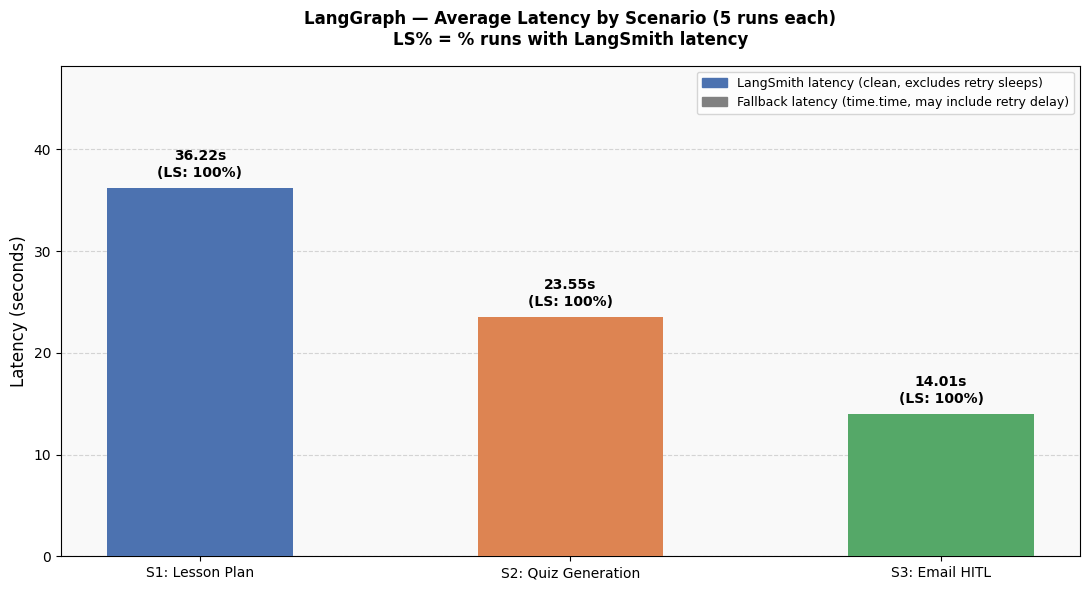

Chart saved: langgraph_latency_chart.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

scenarios_raw = ["Scenario 1 - Lesson Plan", "Scenario 2 - Quiz Generation", "Scenario 3 - Email HITL"]
labels        = ["S1: Lesson Plan", "S2: Quiz Generation", "S3: Email HITL"]
colors        = ["#4C72B0", "#DD8452", "#55A868"]

avg_latencies = []
ls_pcts       = []

for s in scenarios_raw:
    subset = df[df["scenario"] == s]["latency_sec"]
    avg_latencies.append(subset.mean())
    pct = (df[df["scenario"] == s]["latency_source"] == "langsmith").mean() * 100
    ls_pcts.append(pct)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(labels, avg_latencies, color=colors, width=0.5, zorder=3)

for bar, val, pct in zip(bars, avg_latencies, ls_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.2f}s\n(LS: {pct:.0f}%)",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title(
    "LangGraph — Average Latency by Scenario (5 runs each)\n"
    "LS% = % runs with LangSmith latency",
    fontsize=12, fontweight="bold", pad=15
)
ax.set_ylabel("Latency (seconds)", fontsize=12)
ax.set_ylim(0, max(avg_latencies) + 12)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.set_facecolor("#f9f9f9")

ls_patch = mpatches.Patch(color="#4C72B0", label="LangSmith latency (clean, excludes retry sleeps)")
fb_patch = mpatches.Patch(color="gray",    label="Fallback latency (time.time, may include retry delay)")
ax.legend(handles=[ls_patch, fb_patch], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("langgraph_latency_chart.png", dpi=150)
plt.show()
print("Chart saved: langgraph_latency_chart.png")

from google.colab import files
files.download("langgraph_latency_chart.png")